# 📰 NewsBot Intelligence System 2.0
## Notebook 03: Topic Modeling & Content Discovery
**Course:** ITAI2373 | **Final Project**

---

### What This Notebook Does
This notebook implements **Topic Modeling** using two industry-standard algorithms:
- **LDA (Latent Dirichlet Allocation)** — probabilistic model that finds hidden topics
- **NMF (Non-negative Matrix Factorization)** — matrix decomposition approach to topic discovery

We also cover:
- Topic visualization and interpretation
- Content clustering by topic
- Topic distribution across news categories
- Identifying dominant themes in the BBC News dataset

**Prerequisite:** Run `01_Data_Exploration.ipynb` first to generate `newsbot_final.csv`

---
## CELL 1: Install & Import Libraries

In [1]:
# ============================================================
# CELL 1: Install & Import All Required Libraries
# ============================================================

!pip install pyLDAvis -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

# pyLDAvis for interactive visualization
import pyLDAvis
import pyLDAvis.lda_model

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

print('✅ All libraries imported successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.1 MB/s eta 0:00:00
✅ All libraries imported successfully!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## CELL 2: Load Dataset

In [2]:
# ============================================================
# CELL 2: Load the Preprocessed Dataset
# ============================================================

# Load from midterm output
# If newsbot_final.csv is not available, load BBC News Train.csv directly
try:
    df = pd.read_csv('newsbot_final.csv')
    print('✅ Loaded newsbot_final.csv from midterm')
except FileNotFoundError:
    df = pd.read_csv('BBC News Train.csv')
    df = df.rename(columns={'Text': 'content', 'Category': 'category'})
    df = df.dropna(subset=['content', 'category']).reset_index(drop=True)
    print('✅ Loaded BBC News Train.csv directly')

print(f'\n📊 Dataset shape: {df.shape}')
print(f'📋 Columns: {df.columns.tolist()}')
print(f'\n🗂️ Category distribution:')
print(df['category'].value_counts())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Loaded newsbot_final.csv from midterm

📊 Dataset shape: (1440, 14)
📋 Columns: ['ArticleId', 'content', 'category', 'cleaned', 'sentiment', 'nouns', 'verbs', 'adjectives', 'adverbs', 'ent_person', 'ent_org', 'ent_gpe', 'ent_date', 'ent_money']

🗂️ Category distribution:
category
sport            342
business         335
politics         266
entertainment    263
tech             234
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 3: Prepare Text for Topic Modeling

In [3]:
# ============================================================
# CELL 3: Text Preparation for Topic Modeling
# ============================================================

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Add domain-specific stopwords that won't help topic discovery
extra_stops = {'said', 'say', 'says', 'told', 'also', 'would', 'could',
               'new', 'one', 'two', 'year', 'years', 'last', 'first',
               'make', 'made', 'like', 'just', 'time', 'people', 'mr', 'ms'}
stop_words.update(extra_stops)

def prepare_for_topics(text):
    """Clean and prepare text specifically for topic modeling."""
    # Lowercase and remove non-alpha
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize and filter
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in stop_words and len(t) > 3
    ]
    return ' '.join(tokens)

# Use cleaned column if available, otherwise process raw content
if 'cleaned' in df.columns:
    df['topic_text'] = df['cleaned'].apply(prepare_for_topics)
    print('✅ Used existing cleaned column')
else:
    print('⏳ Preprocessing text for topic modeling...')
    df['topic_text'] = df['content'].apply(prepare_for_topics)
    print('✅ Preprocessing complete!')

print(f'\n📝 Sample prepared text:')
print(df['topic_text'].iloc[0][:300])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Used existing cleaned column

📝 Sample prepared text:
worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company whistleblower witness cynthia cooper worldcom exhead internal accounting alerted director irregular accounting practice telecom giant warning collapse firm following discovery acco


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 4: Build Document-Term Matrix

In [4]:
# ============================================================
# CELL 4: Vectorize Text — Build Document-Term Matrix
# ============================================================

# Count Vectorizer for LDA (LDA needs raw counts, not TF-IDF)
count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=5,          # word must appear in at least 5 docs
    max_df=0.90,       # ignore words in more than 90% of docs
    ngram_range=(1, 2) # include bigrams
)

# TF-IDF Vectorizer for NMF
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 2)
)

# Fit and transform
dtm_count = count_vectorizer.fit_transform(df['topic_text'])
dtm_tfidf = tfidf_vectorizer.fit_transform(df['topic_text'])

print(f'✅ Document-Term Matrix built!')
print(f'   Count DTM shape : {dtm_count.shape}')
print(f'   TF-IDF DTM shape: {dtm_tfidf.shape}')
print(f'   ({dtm_count.shape[0]} articles × {dtm_count.shape[1]} unique terms)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Document-Term Matrix built!
   Count DTM shape : (1440, 3000)
   TF-IDF DTM shape: (1440, 3000)
   (1440 articles × 3000 unique terms)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 5: LDA Topic Modeling

In [5]:
# ============================================================
# CELL 5: LDA — Latent Dirichlet Allocation
# ============================================================
# LDA assumes each document is a mixture of topics, and each
# topic is a mixture of words. It finds these hidden patterns.

N_TOPICS = 10  # We want to discover 10 topics

print(f'⏳ Training LDA model with {N_TOPICS} topics...')

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=15,
    learning_method='online',
    random_state=42,
    n_jobs=-1
)

lda_output = lda_model.fit_transform(dtm_count)

print(f'✅ LDA training complete!')
print(f'   Output shape: {lda_output.shape}')
print(f'   (Each article now has a probability score for each of {N_TOPICS} topics)')
print(f'\n📊 Model perplexity: {lda_model.perplexity(dtm_count):.2f}')
print('   (Lower perplexity = better model fit)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⏳ Training LDA model with 10 topics...


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

✅ LDA training complete!
   Output shape: (1440, 10)
   (Each article now has a probability score for each of 10 topics)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


📊 Model perplexity: 1301.71
   (Lower perplexity = better model fit)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 6: Display LDA Topics

In [6]:
# ============================================================
# CELL 6: Display LDA Topics and Top Words
# ============================================================

def display_topics(model, feature_names, n_top_words=12):
    """Print top words for each discovered topic."""
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics[topic_idx] = top_words
    return topics

lda_feature_names = count_vectorizer.get_feature_names_out()
lda_topics = display_topics(lda_model, lda_feature_names)

# Manual topic labels based on what words appear
# (You can adjust these after seeing your results)
topic_labels = {
    0: 'Topic 0', 1: 'Topic 1', 2: 'Topic 2', 3: 'Topic 3',
    4: 'Topic 4', 5: 'Topic 5', 6: 'Topic 6', 7: 'Topic 7',
    8: 'Topic 8', 9: 'Topic 9'
}

print('🔑 LDA DISCOVERED TOPICS')
print('=' * 60)
for topic_id, words in lda_topics.items():
    print(f'\nTopic {topic_id}: {topic_labels[topic_id]}')
    print(f'  Top words: {" | ".join(words[:8])}')

print('\n💡 TIP: Look at the top words and rename topic_labels above!')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

🔑 LDA DISCOVERED TOPICS

Topic 0: Topic 0
  Top words: lord | government | child | home | police | right | secretary | bill

Topic 1: Topic 1
  Top words: court | company | yukos | case | legal | firm | fraud | charge

Topic 2: Topic 2
  Top words: show | music | band | number | song | chart | album | record

Topic 3: Topic 3
  Top words: country | european | world | foreign | meeting | europe | minister | straw

Topic 4: Topic 4
  Top words: technology | mobile | phone | service | game | digital | music | user

Topic 5: Topic 5
  Top words: email | security | virus | program | attack | site | drug | firm

Topic 6: Topic 6
  Top words: market | company | sale | growth | firm | price | share | economy

Topic 7: Topic 7
  Top words: film | best | award | actor | director | star | oscar | actress

Topic 8: Topic 8
  Top words: labour | election | party | government | blair | brown | tory | minister

Topic 9: Topic 9
  Top words: game | england | player | club | world | back | match | team

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 7: Visualize LDA Topics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

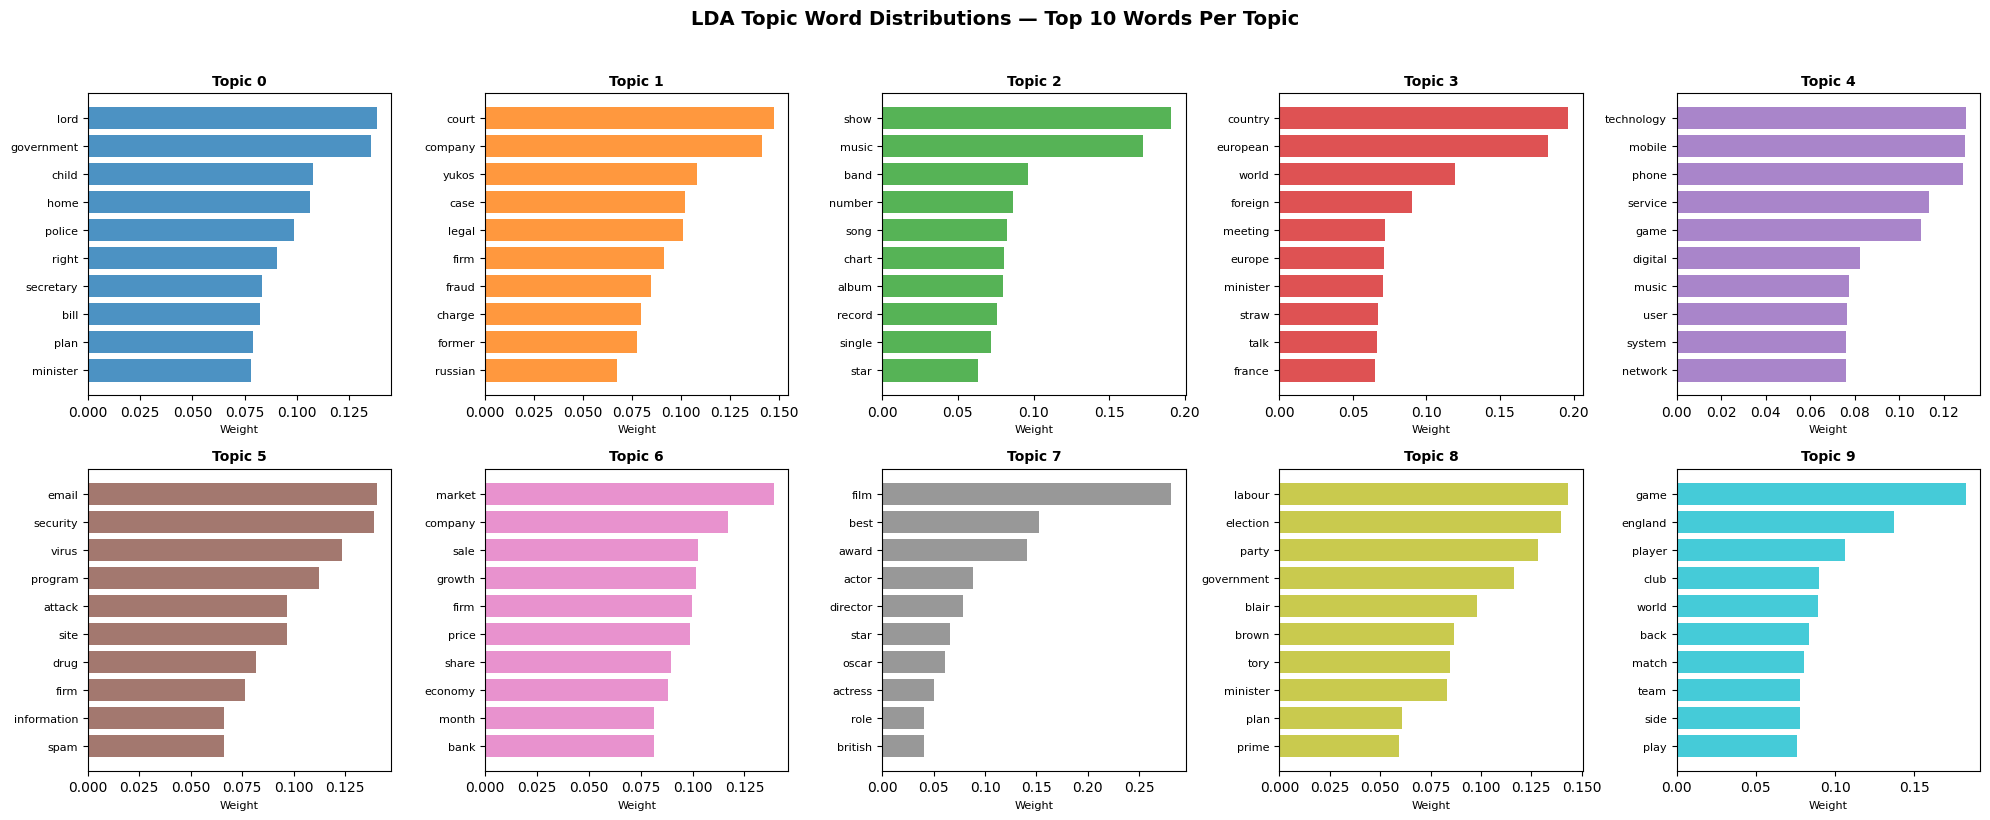

✅ Topic word chart saved as lda_topic_words.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# ============================================================
# CELL 7: Visualize LDA Topic Word Distributions
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, N_TOPICS))

for topic_idx, (topic_id, words) in enumerate(lda_topics.items()):
    ax = axes[topic_idx]

    # Get word weights for this topic
    topic_weights = lda_model.components_[topic_idx]
    top_indices = topic_weights.argsort()[:-11:-1]
    top_words = [lda_feature_names[i] for i in top_indices]
    top_weights = [topic_weights[i] for i in top_indices]

    # Normalize weights for display
    top_weights = np.array(top_weights)
    top_weights = top_weights / top_weights.sum()

    bars = ax.barh(range(len(top_words)), top_weights[::-1],
                   color=colors[topic_idx], alpha=0.8)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words[::-1], fontsize=8)
    ax.set_title(f'Topic {topic_idx}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Weight', fontsize=8)

plt.suptitle('LDA Topic Word Distributions — Top 10 Words Per Topic',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lda_topic_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Topic word chart saved as lda_topic_words.png')

---
## CELL 8: NMF Topic Modeling

In [8]:
# ============================================================
# CELL 8: NMF — Non-Negative Matrix Factorization
# ============================================================
# NMF decomposes the TF-IDF matrix into topics. It tends to
# produce cleaner, more coherent topics than LDA in many cases.

print(f'⏳ Training NMF model with {N_TOPICS} topics...')

nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=300
)

nmf_output = nmf_model.fit_transform(dtm_tfidf)

print(f'✅ NMF training complete!')

# Display NMF topics
nmf_feature_names = tfidf_vectorizer.get_feature_names_out()
nmf_topics = display_topics(nmf_model, nmf_feature_names)

print('\n🔑 NMF DISCOVERED TOPICS')
print('=' * 60)
for topic_id, words in nmf_topics.items():
    print(f'\nTopic {topic_id}:')
    print(f'  Top words: {" | ".join(words[:8])}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⏳ Training NMF model with 10 topics...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ NMF training complete!

🔑 NMF DISCOVERED TOPICS

Topic 0:
  Top words: government | lord | bill | police | court | secretary | home | plan

Topic 1:
  Top words: film | award | best | actor | oscar | actress | star | festival

Topic 2:
  Top words: labour | election | blair | party | brown | tory | prime | prime minister

Topic 3:
  Top words: england | wale | ireland | game | france | robinson | rugby | nation

Topic 4:
  Top words: mobile | phone | technology | service | user | gadget | broadband | digital

Topic 5:
  Top words: growth | economy | rate | economic | dollar | bank | price | rise

Topic 6:
  Top words: band | music | album | chart | song | single | show | number

Topic 7:
  Top words: chelsea | club | game | arsenal | united | league | liverpool | player

Topic 8:
  Top words: open | champion | seed | world | australian | final | olympic | australian open

Topic 9:
  Top words: firm | company | share | profit | sale | market | deal | business


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 9: Compare LDA vs NMF

In [9]:
# ============================================================
# CELL 9: Side-by-Side Comparison — LDA vs NMF
# ============================================================

print('📊 LDA vs NMF TOPIC COMPARISON')
print('=' * 70)
print(f'{"Topic":<8} {"LDA Top Words":<35} {"NMF Top Words":<35}')
print('-' * 70)

for i in range(N_TOPICS):
    lda_words = ', '.join(lda_topics[i][:4])
    nmf_words = ', '.join(nmf_topics[i][:4])
    print(f'Topic {i:<3} {lda_words:<35} {nmf_words:<35}')

print('\n💡 ANALYSIS:')
print('  LDA tends to produce broader, more mixed topics')
print('  NMF tends to produce sharper, more specific topics')
print('  Compare which method better matches the 5 BBC categories')

📊 LDA vs NMF TOPIC COMPARISON
Topic    LDA Top Words                       NMF Top Words                      
----------------------------------------------------------------------
Topic 0   lord, government, child, home       government, lord, bill, police     
Topic 1   court, company, yukos, case         film, award, best, actor           
Topic 2   show, music, band, number           labour, election, blair, party     
Topic 3   country, european, world, foreign   england, wale, ireland, game       
Topic 4   technology, mobile, phone, service  mobile, phone, technology, service 
Topic 5   email, security, virus, program     growth, economy, rate, economic    
Topic 6   market, company, sale, growth       band, music, album, chart          
Topic 7   film, best, award, actor            chelsea, club, game, arsenal       
Topic 8   labour, election, party, government open, champion, seed, world        
Topic 9   game, england, player, club         firm, company, share, profit      

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 10: Assign Topics to Articles

In [10]:
# ============================================================
# CELL 10: Assign Dominant Topic to Each Article
# ============================================================

# Each article gets assigned its dominant (highest probability) topic
df['lda_topic'] = lda_output.argmax(axis=1)
df['lda_topic_prob'] = lda_output.max(axis=1)

df['nmf_topic'] = nmf_output.argmax(axis=1)
df['nmf_topic_prob'] = nmf_output.max(axis=1)

print('✅ Topics assigned to all articles!')
print(f'\n📊 LDA Topic Distribution:')
print(df['lda_topic'].value_counts().sort_index())

print(f'\n📊 NMF Topic Distribution:')
print(df['nmf_topic'].value_counts().sort_index())

print(f'\n📝 Sample article topic assignments:')
print(df[['category', 'lda_topic', 'lda_topic_prob',
          'nmf_topic', 'nmf_topic_prob']].head(10).to_string())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Topics assigned to all articles!

📊 LDA Topic Distribution:
lda_topic
0     94
1     40
2    171
3     22
4    206
5     33
6    290
7     87
8    172
9    325
Name: count, dtype: int64

📊 NMF Topic Distribution:
nmf_topic
0    111
1    131
2    152
3    106
4    212
5    112
6    130
7    131
8    132
9    223
Name: count, dtype: int64

📝 Sample article topic assignments:
        category  lda_topic  lda_topic_prob  nmf_topic  nmf_topic_prob
0       business          1        0.992799          9        0.104297
1       business          6        0.994078          5        0.268337
2       business          6        0.640485          5        0.127971
3           tech          4        0.996265          4        0.268603
4       business          1        0.561285          9        0.165737
5       politics          8        0.401442          2        0.053254
6          sport          9        0.993477          3        0.210147
7  entertainment          7        0.487849          1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 11: Topic Distribution by Category

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

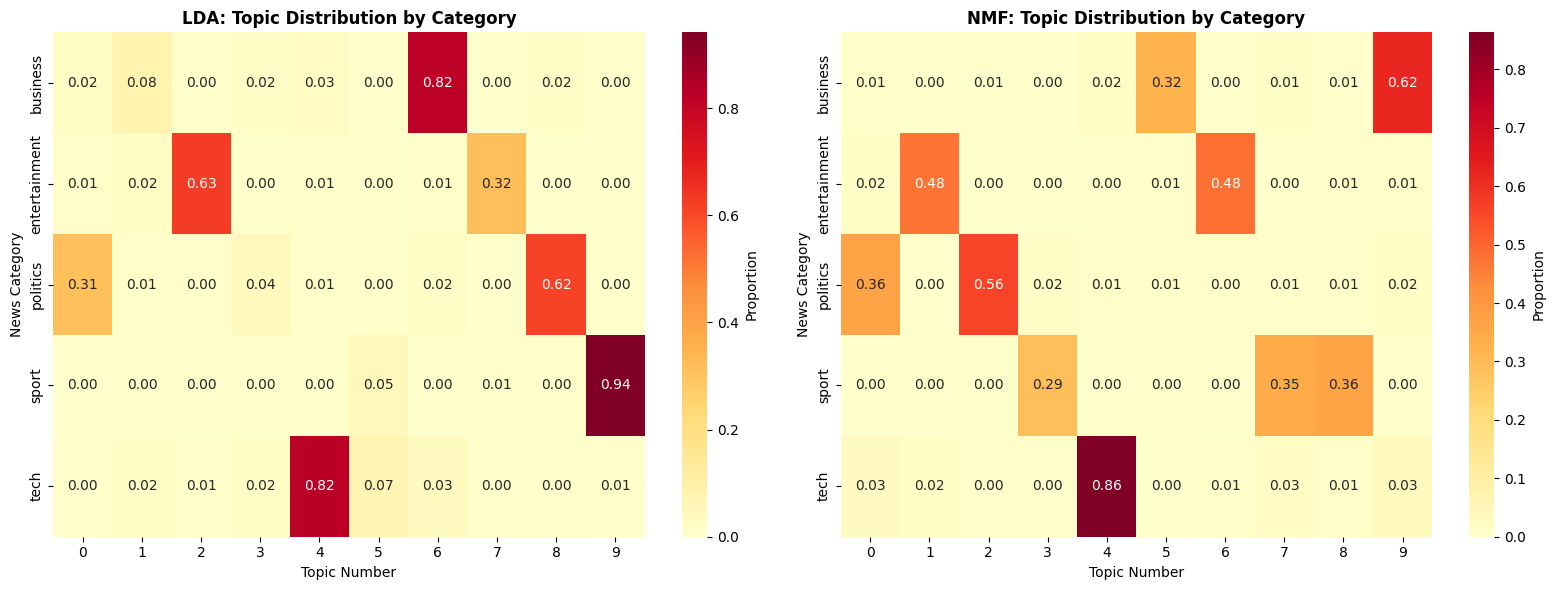

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ Heatmap saved as topic_category_heatmap.png

💡 Bright cells = strong relationship between that category and topic
   Look for diagonal patterns = good topic separation


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
# ============================================================
# CELL 11: Topic Distribution Across News Categories
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LDA heatmap
lda_pivot = pd.crosstab(df['category'], df['lda_topic'])
lda_pivot_norm = lda_pivot.div(lda_pivot.sum(axis=1), axis=0)

sns.heatmap(lda_pivot_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Proportion'})
axes[0].set_title('LDA: Topic Distribution by Category', fontweight='bold')
axes[0].set_xlabel('Topic Number')
axes[0].set_ylabel('News Category')

# NMF heatmap
nmf_pivot = pd.crosstab(df['category'], df['nmf_topic'])
nmf_pivot_norm = nmf_pivot.div(nmf_pivot.sum(axis=1), axis=0)

sns.heatmap(nmf_pivot_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('NMF: Topic Distribution by Category', fontweight='bold')
axes[1].set_xlabel('Topic Number')
axes[1].set_ylabel('News Category')

plt.tight_layout()
plt.savefig('topic_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Heatmap saved as topic_category_heatmap.png')
print('\n💡 Bright cells = strong relationship between that category and topic')
print('   Look for diagonal patterns = good topic separation')

---
## CELL 12: Content Clustering by Topic

In [12]:
# ============================================================
# CELL 12: Content Clustering — Group Similar Articles by Topic
# ============================================================

print('📰 SAMPLE ARTICLES PER LDA TOPIC')
print('=' * 60)

for topic_id in range(N_TOPICS):
    # Get articles most strongly belonging to this topic
    topic_articles = df[df['lda_topic'] == topic_id].nlargest(2, 'lda_topic_prob')

    top_words = ' | '.join(lda_topics[topic_id][:5])
    print(f'\n🔷 Topic {topic_id} — Keywords: {top_words}')

    for _, row in topic_articles.iterrows():
        snippet = row['content'][:150].replace('\n', ' ')
        print(f'   [{row["category"].upper()}] {snippet}...')
        print(f'   Confidence: {row["lda_topic_prob"]:.3f}')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

📰 SAMPLE ARTICLES PER LDA TOPIC

🔷 Topic 0 — Keywords: lord | government | child | home | police
   [POLITICS] goldsmith denies war advice claim the attorney general has denied his statement to parliament about the legality of the iraq war was drafted by downin...
   Confidence: 0.997
   [POLITICS] iraq advice claim sparks new row the tories say ministers must respond in parliament to claims that the legal advice used to justify the iraq war was ...
   Confidence: 0.997

🔷 Topic 1 — Keywords: court | company | yukos | case | legal
   [BUSINESS] worldcom director admits lying the former chief financial officer at us telecoms firm worldcom has admitted before a new york court that he used to li...
   Confidence: 0.994
   [BUSINESS] ebbers denies worldcom fraud former worldcom chief bernie ebbers has denied claims that he knew accountants were doctoring the books at the firm.  spe...
   Confidence: 0.994

🔷 Topic 2 — Keywords: show | music | band | number | song
   [ENTERTAINMENT] dj doub

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 13: Topic Confidence Distribution

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

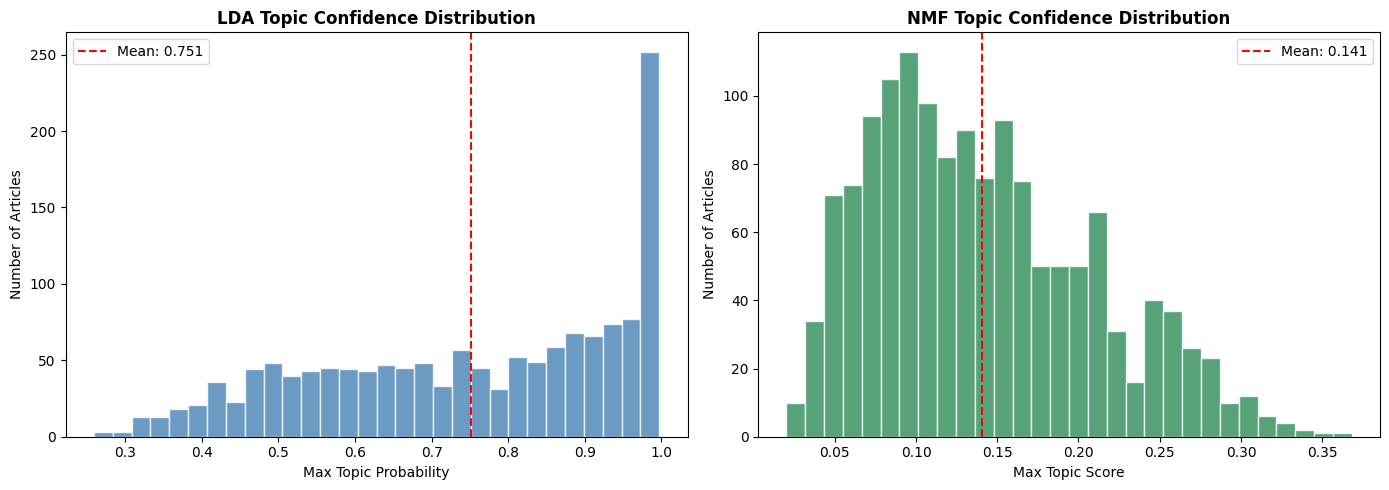


📊 LDA Confidence Stats:
   Mean : 0.751
   Min  : 0.259
   Max  : 0.997

📊 NMF Confidence Stats:
   Mean : 0.141
   Min  : 0.020
   Max  : 0.368


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
# ============================================================
# CELL 13: Topic Confidence Score Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDA confidence distribution
axes[0].hist(df['lda_topic_prob'], bins=30, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(df['lda_topic_prob'].mean(), color='red',
                linestyle='--', label=f'Mean: {df["lda_topic_prob"].mean():.3f}')
axes[0].set_title('LDA Topic Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Max Topic Probability')
axes[0].set_ylabel('Number of Articles')
axes[0].legend()

# NMF confidence distribution
axes[1].hist(df['nmf_topic_prob'], bins=30, color='seagreen',
             edgecolor='white', alpha=0.8)
axes[1].axvline(df['nmf_topic_prob'].mean(), color='red',
                linestyle='--', label=f'Mean: {df["nmf_topic_prob"].mean():.3f}')
axes[1].set_title('NMF Topic Confidence Distribution', fontweight='bold')
axes[1].set_xlabel('Max Topic Score')
axes[1].set_ylabel('Number of Articles')
axes[1].legend()

plt.tight_layout()
plt.savefig('topic_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 LDA Confidence Stats:')
print(f'   Mean : {df["lda_topic_prob"].mean():.3f}')
print(f'   Min  : {df["lda_topic_prob"].min():.3f}')
print(f'   Max  : {df["lda_topic_prob"].max():.3f}')

print(f'\n📊 NMF Confidence Stats:')
print(f'   Mean : {df["nmf_topic_prob"].mean():.3f}')
print(f'   Min  : {df["nmf_topic_prob"].min():.3f}')
print(f'   Max  : {df["nmf_topic_prob"].max():.3f}')

---
## CELL 14: Interactive LDA Visualization

In [14]:
# ============================================================
# CELL 14: Interactive pyLDAvis Visualization
# ============================================================
# This creates an interactive visualization you can explore:
# - Each bubble = one topic
# - Bubble size = how common the topic is
# - Distance between bubbles = how different the topics are
# - Bar chart on right = top words for selected topic

print('⏳ Generating interactive LDA visualization...')

pyLDAvis.enable_notebook()

lda_viz = pyLDAvis.lda_model.prepare(
    lda_model,
    dtm_count,
    count_vectorizer,
    mds='tsne'
)

# Save to HTML file
pyLDAvis.save_html(lda_viz, 'lda_visualization.html')
print('✅ Interactive visualization saved as lda_visualization.html')
print('   Download and open in your browser to explore!')

# Display inline
lda_viz

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⏳ Generating interactive LDA visualization...


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

✅ Interactive visualization saved as lda_visualization.html
   Download and open in your browser to explore!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
9      32.659473 -49.814671       1        1  19.098381
6     -33.448841  52.721794       2        1  17.485404
4     -14.703264 -60.535961       3        1  16.256695
8      47.468952   2.782878       4        1  14.422928
2      20.171267  41.511829       5        1   9.292373
0     -61.966587  11.638361       6        1   8.500565
7       9.969570 -15.389915       7        1   5.383009
1     -30.008945 -19.894833       8        1   3.534908
5     -13.898089  16.822010       9        1   3.037215
3     -64.878181 -40.819145      10        1   2.988522, topic_info=               Term        Freq       Total Category  logprob  loglift
1019           film  737.000000  737.000000  Default  30.0000  30.0000
273            best  544.000000  544.000000  Default  29.0000  29.0000
607         country  538.000000  538.000000  Default  28.0000  28.0000
522         company  645.000000  645.000000  Default  27.0000  27.0000
210           award  360.000000  360.000000  Default  26.0000  26.0000
...             ...         ...         ...      ...      ...      ...
2551          state   50.639895  220.144545  Topic10  -4.7901   2.0408
1386  international   52.779193  290.360755  Topic10  -4.7488   1.8054
2761          trade   41.046118  163.548282  Topic10  -5.0002   2.1280
1578         london   42.406357  318.281453  Topic10  -4.9676   1.4948
662            deal   41.005999  322.376398  Topic10  -5.0012   1.4484

[638 rows x 6 columns], token_table=      Topic      Freq             Term
term                                  
6         5  0.120795          academy
6         7  0.875766          academy
7         7  0.964444    academy award
15        2  0.084745       accounting
15        8  0.903943       accounting
...     ...       ...              ...
2996      4  0.037470          yugansk
2996      8  0.936744          yugansk
2997      8  0.927987  yuganskneftegas
2998      4  0.016940            yukos
2998      8  0.982519            yukos

[1742 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[10, 7, 5, 9, 3, 1, 8, 2, 6, 4])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## CELL 15: Topic Search Function

In [15]:
# ============================================================
# CELL 15: Topic-Based Article Search
# ============================================================

def find_articles_by_topic(topic_id, model_type='lda', top_n=5):
    """
    Find the most representative articles for a given topic.

    Parameters:
        topic_id   : int — topic number (0 to N_TOPICS-1)
        model_type : str — 'lda' or 'nmf'
        top_n      : int — how many articles to return
    """
    prob_col = f'{model_type}_topic_prob'
    topic_col = f'{model_type}_topic'

    results = df[df[topic_col] == topic_id].nlargest(top_n, prob_col)

    topic_dict = lda_topics if model_type == 'lda' else nmf_topics
    keywords = ' | '.join(topic_dict[topic_id][:6])

    print(f'\n🔍 Top {top_n} articles for {model_type.upper()} Topic {topic_id}')
    print(f'   Keywords: {keywords}')
    print('=' * 60)

    for i, (_, row) in enumerate(results.iterrows(), 1):
        print(f'\n{i}. [{row["category"].upper()}] Confidence: {row[prob_col]:.3f}')
        print(f'   {row["content"][:200]}...')

# Example: search topic 0 using LDA
find_articles_by_topic(topic_id=0, model_type='lda', top_n=3)

# Try topic 1 with NMF
find_articles_by_topic(topic_id=1, model_type='nmf', top_n=3)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


🔍 Top 3 articles for LDA Topic 0
   Keywords: lord | government | child | home | police | right

1. [POLITICS] Confidence: 0.997
   goldsmith denies war advice claim the attorney general has denied his statement to parliament about the legality of the iraq war was drafted by downing street officials.  lord goldsmith said lord falc...

2. [POLITICS] Confidence: 0.997
   iraq advice claim sparks new row the tories say ministers must respond in parliament to claims that the legal advice used to justify the iraq war was drawn up at number 10.  downing street has denied ...

3. [POLITICS] Confidence: 0.997
   terror suspects face house arrest uk citizens suspected of involvement in terrorism could face house arrest as part of a series of new measures outlined by the home secretary.  it comes after law lord...

🔍 Top 3 articles for NMF Topic 1
   Keywords: film | award | best | actor | oscar | actress

1. [ENTERTAINMENT] Confidence: 0.293
   bafta to hand out movie honours movie stars from 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

---
## CELL 16: Final Summary

In [16]:
# ============================================================
# CELL 16: Topic Modeling Summary & Business Insights
# ============================================================

print('=' * 60)
print('   📰 TOPIC MODELING — FINAL SUMMARY')
print('=' * 60)

print(f'''
📦 DATASET
----------
  Articles analyzed : {len(df)}
  Topics discovered : {N_TOPICS}
  Vocabulary size   : {dtm_count.shape[1]} unique terms

🤖 MODELS TRAINED
-----------------
  LDA Perplexity    : {lda_model.perplexity(dtm_count):.2f}
  LDA Avg Confidence: {df["lda_topic_prob"].mean():.3f}
  NMF Avg Confidence: {df["nmf_topic_prob"].mean():.3f}

🔑 KEY FINDINGS
---------------
  Most common LDA topic : Topic {df["lda_topic"].mode()[0]}
  Most common NMF topic : Topic {df["nmf_topic"].mode()[0]}
  High confidence (>0.5): {(df["lda_topic_prob"] > 0.5).sum()} articles

💼 BUSINESS VALUE
-----------------
  ✅ Automatic theme discovery without manual labeling
  ✅ Content clustering enables personalized news feeds
  ✅ Emerging topic detection for trend monitoring
  ✅ Topic search enables semantic content retrieval
  ✅ Cross-category topic analysis reveals editorial patterns

📁 FILES SAVED
--------------
  lda_topic_words.png       — Word distributions per topic
  topic_category_heatmap.png— Topic vs category relationships
  topic_confidence.png      — Model confidence distributions
  lda_visualization.html    — Interactive topic explorer
''')

# Save enriched dataset
df.to_csv('newsbot_with_topics.csv', index=False)
print('💾 Enriched dataset saved as newsbot_with_topics.csv')
print('\n✅ Notebook 03: Topic Modeling Complete!')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   📰 TOPIC MODELING — FINAL SUMMARY


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


📦 DATASET
----------
  Articles analyzed : 1440
  Topics discovered : 10
  Vocabulary size   : 3000 unique terms

🤖 MODELS TRAINED
-----------------
  LDA Perplexity    : 1301.71
  LDA Avg Confidence: 0.751
  NMF Avg Confidence: 0.141

🔑 KEY FINDINGS
---------------
  Most common LDA topic : Topic 9
  Most common NMF topic : Topic 9
  High confidence (>0.5): 1230 articles

💼 BUSINESS VALUE
-----------------
  ✅ Automatic theme discovery without manual labeling
  ✅ Content clustering enables personalized news feeds
  ✅ Emerging topic detection for trend monitoring
  ✅ Topic search enables semantic content retrieval
  ✅ Cross-category topic analysis reveals editorial patterns

📁 FILES SAVED
--------------
  lda_topic_words.png       — Word distributions per topic
  topic_category_heatmap.png— Topic vs category relationships
  topic_confidence.png      — Model confidence distributions
  lda_visualization.html    — Interactive topic explorer



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

💾 Enriched dataset saved as newsbot_with_topics.csv

✅ Notebook 03: Topic Modeling Complete!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag